# This notebook uses the weights of the trained model after grid search. It will explore where the model is struggling more to make accurate predictions using the test samples 

# Defining input data

In [2]:
from pathlib import Path
import os

In [16]:
from pathlib import Path
import os
data_path = Path('/kaggle/input/competitions/biohub-cell-tracking-during-development')
training_path =  data_path/'train'
TRAINING_PATH = training_path
test_path = data_path/'test'

#------------ Listing folders in train -----------
print("Input contents:", os.listdir(training_path)[:5],"\n")
print(" First 5 elements in train folder, it contains '.geff' folders (annotated graphs) and '.zarr' folder (videos)")


Input contents: ['6bba_2540cd90.geff', '44b6_0b24845f.geff', '44b6_996155de.geff', '44b6_0c582fdc.geff', '6bba_cf35214c.zarr'] 

 First 5 elements in train folder, it contains '.geff' folders (annotated graphs) and '.zarr' folder (videos)


# Making a prediction with the baseline model

The notebook used to run the baseline can be found here: https://www.kaggle.com/code/thibautgoldsborough/unet-baseline-inference-submission

## Configuration

In [5]:

COMP_DIR = data_path
TEST_DIR = test_path

ARTIFACTS = "/kaggle/input/datasets/thibautgoldsborough/cellmot-baseline-artifacts/cellmot-baseline-artifacts"

REPO_DIR = "/kaggle/working/repo"
METHOD = "unet_transformer"

# --- Test-time options (tune these) ---------------------------------------
# Model checkpoint (relative to the repo, or an absolute path to your own).
WEIGHTS = "/kaggle/input/notebooks/sebastianvpal/improving-baseline-model-part4/cellmot-baseline-artifacts/repo/weights/Training_01/split_0/edge_predictor_best.pth"#f"weights/{METHOD}/split_0/edge_predictor_best.pth"

# GT: Ground-Truth
# Detection peak threshold. GT is sparse so the detector is poorly calibrated;
# 0.5 is too low, ~0.99 scored best in a sweep.
DET_THRESHOLD = 0.99

UNET_BATCH_SIZE = 4          # frame-pairs per UNet forward; lower if you OOM
SLICE = ":"                   # e.g. ":5" to predict only the first 5 videos; "" = all

# Linking. ILP = global, flow-consistent (cleaner tracks; ~0.73->0.79).
# Set False for the faster greedy linker.
USE_ILP = True
ILP_EDGE_WEIGHT = -1.0           # weight on edge probability
ILP_APPEARANCE_WEIGHT = 0.1      # cost of a track appearing
ILP_DISAPPEARANCE_WEIGHT = 0.1   # cost of a track disappearing
ILP_DIVISION_WEIGHT = 1.0        # cost of a division; lower (~0.2) allows more splits
# --------------------------------------------------------------------------

## Offline install & setup
Install the dependencies from the bundled wheels (no internet), then copy the repo source and weights into a writable location and put the package on the import path

In [6]:
import glob
import os
import subprocess
import sys
import shutil

# 1. Find all wheels, but filter OUT numpy wheels to avoid breaking C-extensions
wheels = [
    f for f in glob.glob(f"{ARTIFACTS}/wheels/*.whl")
    if "numpy" not in os.path.basename(f).lower()
]

# 2. Install only the required non-NumPy wheels without upgrading dependencies
subprocess.run(
    [
        "pip", "install", 
        "--no-index", 
        "--find-links", f"{ARTIFACTS}/wheels",
        "--no-deps",
        *wheels
    ],
    check=True,
)

# 3. Copy repo and weights as usual
shutil.copytree(f"{ARTIFACTS}/repo", REPO_DIR, dirs_exist_ok=True)
#shutil.copytree(f"{ARTIFACTS}/weights", f"{REPO_DIR}/weights", dirs_exist_ok=True)
sys.path.insert(0, f"{REPO_DIR}/src")

Looking in links: /kaggle/input/datasets/thibautgoldsborough/cellmot-baseline-artifacts/cellmot-baseline-artifacts/wheels
Processing /kaggle/input/datasets/thibautgoldsborough/cellmot-baseline-artifacts/cellmot-baseline-artifacts/wheels/imagecodecs-2026.6.26-cp312-abi3-manylinux_2_28_x86_64.whl
Processing /kaggle/input/datasets/thibautgoldsborough/cellmot-baseline-artifacts/cellmot-baseline-artifacts/wheels/shellingham-1.5.4-py2.py3-none-any.whl
Processing /kaggle/input/datasets/thibautgoldsborough/cellmot-baseline-artifacts/cellmot-baseline-artifacts/wheels/numcodecs-0.15.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl
Processing /kaggle/input/datasets/thibautgoldsborough/cellmot-baseline-artifacts/cellmot-baseline-artifacts/wheels/bidict-0.23.1-py3-none-any.whl
Processing /kaggle/input/datasets/thibautgoldsborough/cellmot-baseline-artifacts/cellmot-baseline-artifacts/wheels/requests-2.34.2-py3-none-any.whl
Processing /kaggle/input/datasets/thibautgoldsborough/cellmot-bas

## Inference on all test videos
Build a one-fold splits file listing every test video, then run prediction. PYTHONPATH=src makes the tracking_cellmot package importable without an internet install. Each video's tracks are exported as a .geff graph.

In [5]:
# train_stems

In [11]:
import json
import random

random.seed(0)

test_dir = Path(TEST_DIR)
training_path = Path(training_path)
if not test_dir.is_dir():
    raise FileNotFoundError(f"TEST_DIR does not exist or is not a directory: {test_dir}")

test_stems = sorted(p.stem for p in test_dir.iterdir() if p.is_dir() and p.suffix == ".zarr")
train_stems = sorted(p.stem for p in training_path.iterdir() if p.is_dir() and p.suffix == ".zarr") 

print("="*10, f" Total number of videos in train folder:{len(train_stems)} ", "="*10, "\n")


# test_stems = sorted(f[:-5] for f in os.listdir(TEST_DIR) if f.endswith(".zarr"))
# train_stems_subset = train_stems[:2] #selecting a fixed number of training samples
train_stems_subset = random.sample(train_stems, min(100,len(train_stems))) #Randomly samples train
                                                #data with a number of elements from n to len(train_samples)


print(f"{len(test_stems)} test videos")
print(f"One element in test_stems is {test_stems[0]}")
print(f" Number of elements in train key for json file: {len(train_stems_subset)}")

with open(f"{REPO_DIR}/kaggle_test_splits.json", "w") as f:
    json.dump([{"split": 0, "train": train_stems_subset, "test": test_stems}], f)

==========  Total number of videos in train folder:199  ========== 

4 test videos
One element in test_stems is 44b6_0113de3b
 Number of elements in train key for json file: 25


In [8]:
#---------- Reading back the json file just created ------------
with open(f"{REPO_DIR}/kaggle_test_splits.json", "r") as f:
    json_file = json.load(f)

json_file

[{'split': 0,
  'train': ['6bba_372c8cb8',
   '6bba_fbc898dc',
   '6bba_4aa14c89',
   '44b6_267148e4',
   '44b6_e31261b4',
   '6bba_74686d6a',
   '6bba_6ca87370',
   '6bba_3fda6b25',
   '6bba_09961292',
   '6bba_6479435d',
   '6bba_2646afc7',
   '6bba_971fa5e0',
   '44b6_cf8fed6b',
   '6bba_718b21f9',
   '44b6_8f5ab931',
   '6bba_05db0fb1',
   '6bba_ebff6e76',
   '44b6_668e0cc7',
   '6bba_af149c94',
   '44b6_e28840c6',
   '6bba_78a7bd97',
   '6bba_ab78413d',
   '44b6_90724892',
   '6bba_0e7c0d07',
   '44b6_66f9292d'],
  'test': ['44b6_0113de3b',
   '44b6_0b24845f',
   '6bba_05b6850b',
   '6bba_05db0fb1']}]

# Run predictions

In [34]:
# =============================================================================
# 1. Greedy nearest-neighbor matching (detections <-> GT), physical-distance based
#    Same style as train_unet_transformer.detect_and_match's own matching logic.
# =============================================================================
def match_greedy(gt_phys: np.ndarray, det_phys: np.ndarray, max_dist: float) -> np.ndarray:
    """Returns a boolean mask over gt_phys: True where a GT node found a match."""
    n_gt, n_det = len(gt_phys), len(det_phys)
    matched_gt = np.zeros(n_gt, dtype=bool)
    if n_gt == 0 or n_det == 0:
        return matched_gt
    dists = np.linalg.norm(gt_phys[:, None, :] - det_phys[None, :, :], axis=-1)  # (n_gt, n_det)
    order = np.argsort(dists, axis=None)
    det_taken = np.zeros(n_det, dtype=bool)
    n_det_cols = dists.shape[1]
    for flat_idx in order:
        gi, di = divmod(flat_idx, n_det_cols)
        if dists[gi, di] > max_dist:
            break
        if matched_gt[gi] or det_taken[di]:
            continue
        matched_gt[gi] = True
        det_taken[di] = True
    return matched_gt


# =============================================================================
# Definition of function to compute local contrast
# =============================================================================
def local_contrast(img: np.ndarray, coord_ds: np.ndarray, radius_vox: tuple[int, int, int]) -> tuple[float, float]:
    """coord_ds: (z, y, x) in the DOWNSAMPLED image grid. radius_vox: per-axis voxel radius (z, y, x)."""
    z, y, x = coord_ds
    rz, ry, rx = radius_vox
    z0, z1 = max(0, z - rz), min(img.shape[0], z + rz + 1)
    y0, y1 = max(0, y - ry), min(img.shape[1], y + ry + 1)
    x0, x1 = max(0, x - rx), min(img.shape[2], x + rx + 1)
    patch = img[z0:z1, y0:y1, x0:x1]
    return patch.mean(), patch.std()


# =============================================================================
# Definition of function to compute local node density
# =============================================================================
def local_crowding(gt_phys: np.ndarray, radius_um: float) -> np.ndarray:
    """
    Count how many OTHER GT nodes fall within radius_um (physical microns)
    ---
    Inputs:
    
    gt_phys: (N,3) array already scaled to physical micron (z,y,x)*voxel_size
    radius_um: search radius in um
    ---
    Outputs:

    Returns: (N,) integer array with the neighbor count per node (excluding itself)
    """
    n = len(gt_phys) #Number of nodes
    if n <= 1:
        return np.zeros(n, dtype=int)
    # Build a spatial tree and count neighbors within radius
    tree = cKDTree(gt_phys)
    # return_length=True counts points within radius. 
    # We subtract 1 to exclude each point counting itself (since distance to self is 0).
    counts = tree.query_ball_point(gt_phys, r=radius_um, return_length=True) - 1
    
    return counts


In [38]:
# =============================================================================
# 0. Setup — fill in these paths/values for your environment
# =============================================================================
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import torch
import zarr
import matplotlib.pyplot as plt
import time
from scipy.spatial import cKDTree

sys.path.insert(0, str(Path(ARTIFACTS) / "repo/src"))       # adjust if different
sys.path.insert(0, str(Path(ARTIFACTS) / "repo/scripts"))   # adjust if different

from tracking_cellmot.io import open_dataset
from predict_unet_transformer import load_model, predict_video, PredictConfig, _load_frame

# --- fill these in ---
BEST_CHECKPOINT_PATH = Path(WEIGHTS)
TRAINING_PATH = Path(data_path) / "train"     # folder containing the video subfolders
val_stems = train_stems_subset #test_stems                        # your held-out validation video stems (list of str)

REAL_DET_THRESHOLD = 0.99      # sigmoid probability threshold — matches predict_unet_transformer's convention
POOL_KERNEL_UM = 3.0           # matches PredictConfig default; use your own tuned value if you have one
USE_TTA = False #True                 # match real submission settings. False to speed up computation at cost of accuracy in calculations
MAX_MATCH_DISTANCE_UM = 7.0    # fixed to the competition's own scoring tolerance
UNET_BATCH_SIZE = 16 #4 #try to increased if possible (take care of OOM errors)

CROWDING_RADIUS_UM = 7.0   # pick based on earlier p10 nearest-neighbor 
#finding (~14 µm) — this checks "how many neighbors within roughly that distance"



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
d_type = torch.float16 if device.type == "cuda" else torch.float16
print(f"device: {device}")

model, window_size, downsample = load_model(BEST_CHECKPOINT_PATH, device)
print(f"window_size={window_size}, downsample={downsample}")

# convert a chosen physical radius (µm) to per-axis voxel counts at the DOWNSAMPLED resolution:
CONTRAST_RADIUS_UM = 5.0



cfg = PredictConfig(det_threshold=REAL_DET_THRESHOLD, det_tta=USE_TTA, pool_kernel_um=POOL_KERNEL_UM)




# =============================================================================
# 2. Per-video pass: real inference (predict_video) + GT matching + density/brightness
# =============================================================================
records = []
time_start = time.time()
for stem in val_stems:
    ds_path = TRAINING_PATH / stem
    print(f"processing {stem} ...")

    # --- 2a. Run the REAL inference pipeline to get detections (original-resolution voxel coords) ---
    with torch.autocast(device_type=device.type, dtype=d_type):
        det_coords, _edges = predict_video(
            model, ds_path, device, cfg=cfg,
            window_size=window_size, unet_batch_size=UNET_BATCH_SIZE, downsample=downsample,
        )
    # det_coords: (N, 4) columns [t, z, y, x], already rescaled back to original resolution

    # --- 2b. Load GT tracks and dataset metadata for this video ---
    ds = open_dataset(ds_path, normalize=False, require_tracks=True, load_image=False, downsample=(1, 1, 1))
    voxel_size_full = np.array(ds.scale, dtype=np.float32)   # physical µm per voxel, ORIGINAL resolution
    zarr_arr = zarr.open_group(str(ds.zarr_path), mode="r")["0"]
    q_low = float(ds.quantiles["0.001"])
    q_high = float(ds.quantiles["0.999"])
    target_shape = list(ds.image_shape[1:])

    gt_attrs = ds.tracks.node_attrs(attr_keys=["t", "z", "y", "x"])

    for t in sorted(gt_attrs["t"].unique().to_list()):
        gt_frame = gt_attrs.filter(pl.col("t") == t)
        gt_zyx = gt_frame.select(["z", "y", "x"]).to_numpy().astype(np.float32)
        if len(gt_zyx) == 0:
            continue

        det_frame = det_coords[det_coords[:, 0] == t][:, 1:].astype(np.float32)

        # --- 2c. Match in PHYSICAL microns (original-resolution scale) ---
        gt_phys = gt_zyx * voxel_size_full
        det_phys = det_frame * voxel_size_full
        matched_mask = match_greedy(gt_phys, det_phys, MAX_MATCH_DISTANCE_UM)

        # --- 2d. Local density: nearest-neighbor distance among GT nodes in this frame (physical µm) ---
        if len(gt_phys) > 1:
            d = np.linalg.norm(gt_phys[:, None, :] - gt_phys[None, :, :], axis=-1)
            np.fill_diagonal(d, np.inf)
            nn_dist = d.min(axis=1)
        else:
            nn_dist = np.full(len(gt_phys), np.nan)

        # --- 2e. Brightness: sample the actual normalized, downsampled image the model saw ---
        imgs = _load_frame(zarr_arr, int(t), target_shape, downsample)          # (Z_ds, Y_ds, X_ds)
        imgs = ((imgs - q_low) / (q_high - q_low + 1e-6)).clamp(0.0).numpy()
        ds_arr = np.array(downsample, dtype=np.float32)
        gt_ds_coords = np.round(gt_zyx / ds_arr).astype(int)
        gt_ds_coords[:, 0] = np.clip(gt_ds_coords[:, 0], 0, imgs.shape[0] - 1)
        gt_ds_coords[:, 1] = np.clip(gt_ds_coords[:, 1], 0, imgs.shape[1] - 1)
        gt_ds_coords[:, 2] = np.clip(gt_ds_coords[:, 2], 0, imgs.shape[2] - 1)
        intensity = imgs[gt_ds_coords[:, 0], gt_ds_coords[:, 1], gt_ds_coords[:, 2]]

        # --- 2f Distance to boundary (voxels, in the downsampled grid used for the image) ---
        Z, Y, X = imgs.shape
        gt_ds = gt_ds_coords # already computed
        dist_to_edge = np.minimum.reduce([
            gt_ds[:, 0], Z - 1 - gt_ds[:, 0],
            gt_ds[:, 1], Y - 1 - gt_ds[:, 1],
            gt_ds[:, 2], X - 1 - gt_ds[:, 2],
        ]) #output is an N array (N number of GT nodes) with the smallest distance to any of the walls

        # --- 2g. Local contrast: mean/std in a small cube around each node ---
        voxel_size_ds = np.array(ds.scale) * np.array(downsample)   # physical µm per voxel, AT the downsampled resolution
        radius_vox = tuple(max(1, round(CONTRAST_RADIUS_UM / s)) for s in voxel_size_ds)  # (rz, ry, rx)
        local_stats = [local_contrast(imgs, c, radius_vox) for c in gt_ds]
        local_mean = np.array([s[0] for s in local_stats]) #mean across all samples
        local_std = np.array([s[1] for s in local_stats]) #standar deviation across all samples
        contrast = (intensity - local_mean) / (local_std + 1e-6) #contrast at each GT node, with respect to the surroundings

        # --- 2h. Local node density
        crowding = local_crowding(gt_phys, CROWDING_RADIUS_UM)
        
        for idx in range(len(gt_zyx)):
            records.append({
                "video_stem": stem,
                "t": int(t),
                "z": gt_zyx[idx, 0], "y": gt_zyx[idx, 1], "x": gt_zyx[idx, 2],
                "detected": bool(matched_mask[idx]),
                "nn_dist_um": float(nn_dist[idx]),
                "intensity_at_node": float(intensity[idx]),
                "dist_to_edge_vox": dist_to_edge[idx],
                "local_contrast": contrast[idx],
                "n_neighbors_within_15um": crowding[idx],
            })
    

print("="*10," Prediction finished ", "="*10,"\n")
print("--- %s seconds ---" % (time.time() - time_start))

df = pd.DataFrame(records)
df.to_parquet("/kaggle/working/node_level_errors.parquet")
print(f"\n{len(df)} GT nodes across {df['video_stem'].nunique()} videos")
print(f"overall recall: {df['detected'].mean():.4f}")


# =============================================================================
# 3. Analysis — quantitative first
# =============================================================================
print(df.groupby("detected")[["nn_dist_um", "intensity_at_node"]].describe())

from scipy import stats
missed_int = df.loc[~df["detected"], "intensity_at_node"].dropna()
found_int = df.loc[df["detected"], "intensity_at_node"].dropna()
missed_nn = df.loc[~df["detected"], "nn_dist_um"].dropna()
found_nn = df.loc[df["detected"], "nn_dist_um"].dropna()

print("\nintensity: missed vs found —", stats.mannwhitneyu(missed_int, found_int))
print("nn_dist:   missed vs found —", stats.mannwhitneyu(missed_nn, found_nn))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df.boxplot(column="nn_dist_um", by="detected", ax=axes[0])
axes[0].set_title("Nearest-neighbor distance (µm) vs detected")
df.boxplot(column="intensity_at_node", by="detected", ax=axes[1])
axes[1].set_title("Intensity at node vs detected")
plt.suptitle("") 
plt.tight_layout() 
plt.show()  

NameError: name 'train_stems_subset' is not defined

In [13]:
((31/2)*35)/3600 #1.3 hours

0.15069444444444444

Text(0.5, 1.0, 'Number neighbors within 15 um')

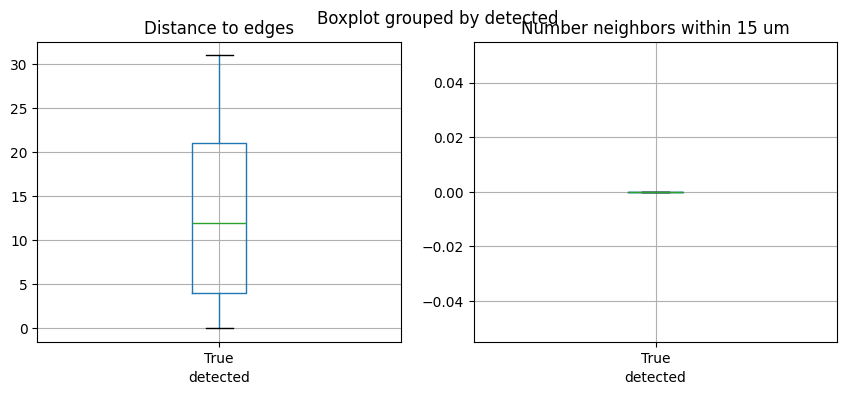

In [10]:

fig, axes = plt.subplots(1,2, figsize = (10,4))
df.boxplot(column="dist_to_edge_vox", by="detected",ax=axes[0])
axes[0].set_title("Distance to edges")
#-
df.boxplot(column="n_neighbors_within_15um",by="detected",ax=axes[1])
axes[1].set_title("Number neighbors within 15 um")

Text(0.5, 1.0, 'local contrast')

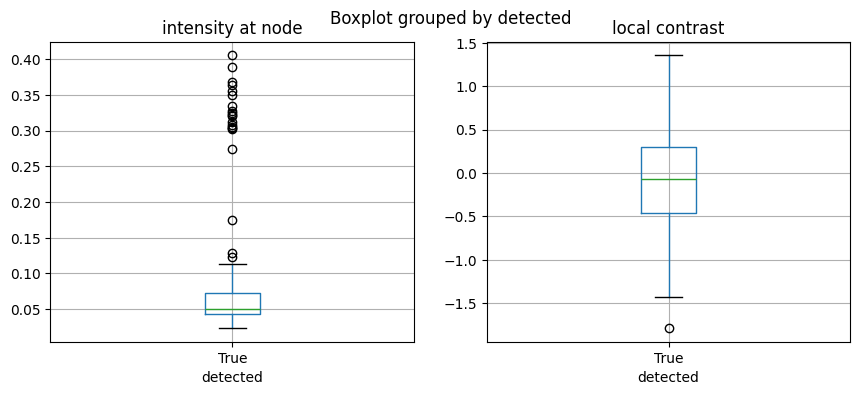

In [11]:
fig,ax = plt.subplots(1,2,figsize=(10,4))
df.boxplot(column="intensity_at_node", by="detected",ax=ax[0])
ax[0].set_title("intensity at node")
#--
df.boxplot(column="local_contrast",by="detected",ax=ax[1])
ax[1].set_title("local contrast")

# 4. Node-level errors using the POST-PROCESSED graph (gap-recovery notebook output)

Same per-GT-node diagnostics as above (recall via matching, local density, intensity,
contrast, distance-to-edge), but using the *final* node positions written by
`biohub-cell-tracking-learned-graph-w-gap-recovery.ipynb` (`submission.csv`, after ILP +
gap-close/gap2/motion-relink repair) instead of raw `predict_video` output. This lets you
diff this parquet against `node_level_errors.parquet` (raw detector) to see what the
post-processing steps actually change at the node level — including new "detections" that
are really synthetic/interpolated nodes inserted by gap-closing, not real model detections.

**Precondition:** `SUBMISSION_CSV_PATH` below must point at a `submission.csv` produced by
running the gap-recovery notebook with `BIOHUB_TEST_DIR` pointed at your **train** folder
(so ground truth exists) — a run against the real hidden test set has no GT to compare
against and this section will find nothing to match.

This section iterates over every dataset stem actually present in `submission.csv` (not
just the `val_stems` subset used in section 2), looking each one up under `TRAINING_PATH`
and skipping (with a warning) any that aren't found there — so it covers however many
videos the gap-recovery run actually produced, e.g. the full train set if it was pointed at
all of it, not only the 25 `val_stems`. The closing `comparison` table is still limited to
stems present in *both* `df` and `df_postprocessed` (via its `.dropna()`), but
`df_postprocessed`/`node_level_errors_postprocessed.parquet` itself can cover a larger set
of videos than section 2's raw-detector run.

No GPU / model inference happens in this cell — `downsample`, `open_dataset`, `_load_frame`,
`match_greedy`, `local_contrast`, and `local_crowding` are all reused from section 2/3 above,
so run this notebook from the top as usual before running this section.

In [46]:
# --- fill these in ---
BEST_CHECKPOINT_PATH = Path(WEIGHTS)
TRAINING_PATH = Path(data_path) / "train"     # folder containing the video subfolders

REAL_DET_THRESHOLD = 0.99      # sigmoid probability threshold — matches predict_unet_transformer's convention
POOL_KERNEL_UM = 3.0           # matches PredictConfig default; use your own tuned value if you have one
USE_TTA = False #True                 # match real submission settings. False to speed up computation at cost of accuracy in calculations
MAX_MATCH_DISTANCE_UM = 7.0    # fixed to the competition's own scoring tolerance
UNET_BATCH_SIZE = 16 #4 #try to increased if possible (take care of OOM errors)

CROWDING_RADIUS_UM = 7.0   # pick based on earlier p10 nearest-neighbor 
#finding (~14 µm) — this checks "how many neighbors within roughly that distance"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, window_size, downsample = load_model(BEST_CHECKPOINT_PATH, device)
CONTRAST_RADIUS_UM = 5.0


In [32]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import torch
import zarr
import matplotlib.pyplot as plt
import time
from scipy.spatial import cKDTree

sys.path.insert(0, str(Path(ARTIFACTS) / "repo/src"))       # adjust if different
sys.path.insert(0, str(Path(ARTIFACTS) / "repo/scripts"))   # adjust if different

from tracking_cellmot.io import open_dataset
from predict_unet_transformer import load_model, predict_video, PredictConfig, _load_frame

In [47]:
# =============================================================================
# 4a. Load the post-processed detections from the gap-recovery notebook's submission.csv
# =============================================================================

# --- fill this in: path to the submission.csv written by
#     biohub-cell-tracking-learned-graph-w-gap-recovery.ipynb when it was run with
#     BIOHUB_TEST_DIR pointed at your train folder (so GT exists to compare against) ---
SUBMISSION_CSV_PATH = Path("/kaggle/input/notebooks/"\
"sebastianvpal/biohub-cell-tracking-learned-graph-w-gap-recovery/submission.csv")

sub_df = pd.read_csv(SUBMISSION_CSV_PATH)
node_rows = sub_df[sub_df["row_type"] == "node"]

# z/y/x in submission.csv are rounded to the nearest voxel (int) by the gap-recovery
# notebook's CSV writer — negligible next to MAX_MATCH_DISTANCE_UM at this voxel scale.
det_coords_by_stem: dict[str, np.ndarray] = {
    stem: grp[["t", "z", "y", "x"]].to_numpy().astype(np.float32)
    for stem, grp in node_rows.groupby("dataset")
}

print(f"Loaded post-processed nodes for {len(det_coords_by_stem)} videos from {SUBMISSION_CSV_PATH}")


# =============================================================================
# 4b. Per-video pass — same as section 2, but det_coords comes from submission.csv
#     instead of predict_video (no model inference here). Iterates over every stem
#     present in submission.csv (not val_stems), looking each one up under
#     TRAINING_PATH so this covers however many videos the gap-recovery run actually
#     produced, not just the val_stems subset used in section 2.
# =============================================================================
records_postprocessed = []
skipped_stems = []
time_start = time.time()
for stem in sorted(det_coords_by_stem):
    ds_path = TRAINING_PATH / stem
    if not (TRAINING_PATH / f"{stem}.geff").exists():
        skipped_stems.append(stem)
        continue
    print(f"processing {stem} ...")

    # --- 4c. Post-processed detections for this video (original-resolution voxel coords) ---
    det_coords = det_coords_by_stem[stem]
    # det_coords: (N, 4) columns [t, z, y, x], same convention as predict_video's output

    # --- 4d. Load GT tracks and dataset metadata for this video (identical to section 2b) ---
    ds = open_dataset(ds_path, normalize=False, require_tracks=True, load_image=False, downsample=(1, 1, 1))
    voxel_size_full = np.array(ds.scale, dtype=np.float32)   # physical µm per voxel, ORIGINAL resolution
    zarr_arr = zarr.open_group(str(ds.zarr_path), mode="r")["0"]
    q_low = float(ds.quantiles["0.001"])
    q_high = float(ds.quantiles["0.999"])
    target_shape = list(ds.image_shape[1:])

    gt_attrs = ds.tracks.node_attrs(attr_keys=["t", "z", "y", "x"])

    for t in sorted(gt_attrs["t"].unique().to_list()):
        gt_frame = gt_attrs.filter(pl.col("t") == t)
        gt_zyx = gt_frame.select(["z", "y", "x"]).to_numpy().astype(np.float32)
        if len(gt_zyx) == 0:
            continue

        det_frame = det_coords[det_coords[:, 0] == t][:, 1:].astype(np.float32)

        # --- 4e. Match in PHYSICAL microns (original-resolution scale) ---
        gt_phys = gt_zyx * voxel_size_full
        det_phys = det_frame * voxel_size_full
        matched_mask = match_greedy(gt_phys, det_phys, MAX_MATCH_DISTANCE_UM)

        # --- 4f. Local density: nearest-neighbor distance among GT nodes in this frame (physical µm) ---
        if len(gt_phys) > 1:
            d = np.linalg.norm(gt_phys[:, None, :] - gt_phys[None, :, :], axis=-1)
            np.fill_diagonal(d, np.inf)
            nn_dist = d.min(axis=1)
        else:
            nn_dist = np.full(len(gt_phys), np.nan)

        # --- 4g. Brightness: sample the actual normalized, downsampled image the model saw ---
        imgs = _load_frame(zarr_arr, int(t), target_shape, downsample)          # (Z_ds, Y_ds, X_ds)
        imgs = ((imgs - q_low) / (q_high - q_low + 1e-6)).clamp(0.0).numpy()
        ds_arr = np.array(downsample, dtype=np.float32)
        gt_ds_coords = np.round(gt_zyx / ds_arr).astype(int)
        gt_ds_coords[:, 0] = np.clip(gt_ds_coords[:, 0], 0, imgs.shape[0] - 1)
        gt_ds_coords[:, 1] = np.clip(gt_ds_coords[:, 1], 0, imgs.shape[1] - 1)
        gt_ds_coords[:, 2] = np.clip(gt_ds_coords[:, 2], 0, imgs.shape[2] - 1)
        intensity = imgs[gt_ds_coords[:, 0], gt_ds_coords[:, 1], gt_ds_coords[:, 2]]

        # --- 4h. Distance to boundary (voxels, in the downsampled grid used for the image) ---
        Z, Y, X = imgs.shape
        gt_ds = gt_ds_coords
        dist_to_edge = np.minimum.reduce([
            gt_ds[:, 0], Z - 1 - gt_ds[:, 0],
            gt_ds[:, 1], Y - 1 - gt_ds[:, 1],
            gt_ds[:, 2], X - 1 - gt_ds[:, 2],
        ])

        # --- 4i. Local contrast: mean/std in a small cube around each node ---
        voxel_size_ds = np.array(ds.scale) * np.array(downsample)   # physical µm per voxel, AT the downsampled resolution
        radius_vox = tuple(max(1, round(CONTRAST_RADIUS_UM / s)) for s in voxel_size_ds)  # (rz, ry, rx)
        local_stats = [local_contrast(imgs, c, radius_vox) for c in gt_ds]
        local_mean = np.array([s[0] for s in local_stats])
        local_std = np.array([s[1] for s in local_stats])
        contrast = (intensity - local_mean) / (local_std + 1e-6)

        # --- 4j. Local node density ---
        crowding = local_crowding(gt_phys, CROWDING_RADIUS_UM)

        for idx in range(len(gt_zyx)):
            records_postprocessed.append({
                "video_stem": stem,
                "t": int(t),
                "z": gt_zyx[idx, 0], "y": gt_zyx[idx, 1], "x": gt_zyx[idx, 2],
                "detected": bool(matched_mask[idx]),
                "nn_dist_um": float(nn_dist[idx]),
                "intensity_at_node": float(intensity[idx]),
                "dist_to_edge_vox": dist_to_edge[idx],
                "local_contrast": contrast[idx],
                "n_neighbors_within_15um": crowding[idx],
            })

print("="*10, " Post-processed node-level errors finished ", "="*10, "\n")
print("--- %s seconds ---" % (time.time() - time_start))
if skipped_stems:
    print(f"WARNING: {len(skipped_stems)} submission.csv stems not found under {TRAINING_PATH} "
          f"(skipped): {skipped_stems[:10]}")

df_postprocessed = pd.DataFrame(records_postprocessed)
df_postprocessed.to_parquet("/kaggle/working/node_level_errors_postprocessed.parquet")
print(f"\n{len(df_postprocessed)} GT nodes across {df_postprocessed['video_stem'].nunique()} videos")
print(f"overall recall (post-processed graph): {df_postprocessed['detected'].mean():.4f}")

# --- quick side-by-side against the raw-detector parquet computed in section 2 ---
# comparison = pd.DataFrame({
#     "raw_detector": df.groupby("video_stem")["detected"].mean(),
#     "post_processed": df_postprocessed.groupby("video_stem")["detected"].mean(),
# }).dropna()
# comparison["delta"] = comparison["post_processed"] - comparison["raw_detector"]
# comparison.sort_values("delta", ascending=False)

Loaded post-processed nodes for 20 videos from /kaggle/input/notebooks/sebastianvpal/biohub-cell-tracking-learned-graph-w-gap-recovery/submission.csv
processing 44b6_267148e4 ...
processing 44b6_668e0cc7 ...
processing 44b6_8f5ab931 ...
processing 44b6_cf8fed6b ...
processing 44b6_e28840c6 ...
processing 44b6_e31261b4 ...
processing 6bba_05db0fb1 ...
processing 6bba_09961292 ...
processing 6bba_2646afc7 ...
processing 6bba_372c8cb8 ...
processing 6bba_3fda6b25 ...
processing 6bba_4aa14c89 ...
processing 6bba_6479435d ...
processing 6bba_6ca87370 ...
processing 6bba_718b21f9 ...
processing 6bba_74686d6a ...
processing 6bba_971fa5e0 ...
processing 6bba_af149c94 ...
processing 6bba_f8ffd5e7 ...
processing 6bba_fbc898dc ...
==========  Post-processed node-level errors finished  ========== 

--- 209.76783537864685 seconds ---

15155 GT nodes across 20 videos
overall recall (post-processed graph): 0.9803


NameError: name 'df' is not defined

In [27]:
ds_path = Path('/kaggle/input/competitions/biohub-cell-tracking-during-development/train/6bba_fbc898dc.geff')#TRAINING_PATH / stem
if not ds_path.exists():
    print("file doesnt exist")

In [24]:
TRAINING_PATH / stem

PosixPath('/kaggle/input/competitions/biohub-cell-tracking-during-development/train/6bba_fbc898dc')

In [12]:
# import subprocess

# # ----------------- command to run "predict_unet_transformer.py" which predicts data ------------------------
# cmd = [
#     "python", "scripts/predict_unet_transformer.py",
#     "--data-dir", str(TEST_DIR), "--splits", "kaggle_test_splits.json", "--split", "0",
#     "--weights", str(WEIGHTS), "--unet-batch-size", str(UNET_BATCH_SIZE),
#     "--det-threshold", str(DET_THRESHOLD),
#     "--ilp-edge-weight", str(ILP_EDGE_WEIGHT),
#     "--ilp-appearance-weight", str(ILP_APPEARANCE_WEIGHT),
#     "--ilp-disappearance-weight", str(ILP_DISAPPEARANCE_WEIGHT),
#     "--ilp-division-weight", str(ILP_DIVISION_WEIGHT),
# ]
# if USE_ILP:
#     cmd.append("--use-ilp")
# if SLICE:
#     cmd += ["--slice", SLICE]

# print(" ".join(cmd))
# subprocess.run(cmd, cwd=REPO_DIR, env={**os.environ, "PYTHONPATH": "src"}, check=True)

# Build submission.csv
Flatten the predicted .geff graphs into the competition's CSV format: one node row per detection (t, z, y, x) and one edge row per link (source_id, target_id)

In [13]:
# from pathlib import Path

# import pandas as pd
# import tracksdata as td

# geffs = sorted(Path(REPO_DIR, "predictions").glob(f"*/{METHOD}/split_0/*.geff"))
# print(f"{len(geffs)} prediction graphs")

# rows = []
# for g in geffs:
#     name = g.stem
#     graph = td.graph.IndexedRXGraph.from_geff(g)
#     graph = graph[0] if isinstance(graph, tuple) else graph
#     for r in graph.node_attrs().iter_rows(named=True):
#         rows.append({
#             "dataset": name, "row_type": "node", "node_id": int(r["node_id"]),
#             "t": int(r["t"]), "z": int(round(r["z"])), "y": int(round(r["y"])),
#             "x": int(round(r["x"])), "source_id": -1, "target_id": -1,
#         })
#     for r in graph.edge_attrs().iter_rows(named=True):
#         rows.append({
#             "dataset": name, "row_type": "edge", "node_id": -1,
#             "t": -1, "z": -1, "y": -1, "x": -1,
#             "source_id": int(r["source_id"]), "target_id": int(r["target_id"]),
#         })

In [14]:
# sample_sub = pd.read_csv('/kaggle/input/competitions/biohub-cell-tracking-during-development/sample_submission.csv')

# # build submission with all data columns first
# submission = pd.DataFrame(rows)

# data_cols = [c for c in sample_sub.columns if c != 'id']

# # fail loudly if anything's missing, rather than silently mismatching Kaggle's grader
# missing = set(data_cols) - set(submission.columns)
# if missing:
#     raise ValueError(f"submission is missing columns required by sample_sub: {missing}")

# # enforce exact column order from sample_sub
# submission = submission[data_cols]

# # cast every column to sample_sub's exact dtype
# for col in data_cols:
#     submission[col] = submission[col].astype(sample_sub[col].dtype)

# # build id explicitly as a real column (not via DataFrame.index), matching sample_sub's id dtype
# submission.insert(0, 'id', range(len(submission)))
# submission['id'] = submission['id'].astype(sample_sub['id'].dtype)

# # final schema check before writing
# assert list(submission.columns) == list(sample_sub.columns), "column order mismatch"
# assert (submission.dtypes == sample_sub.dtypes).all(), submission.dtypes.compare(sample_sub.dtypes)

# submission.to_csv("submission.csv", index=False)
# print(f"Wrote submission.csv with {len(submission)} rows")
# submission.head()

In [15]:
# import shutil
# import os

# repo_path = REPO_DIR  # adjust if your folder is elsewhere

# if os.path.exists(repo_path):
#     shutil.rmtree(repo_path)
#     print(f"Removed {repo_path}")
# else:
#     print("No repo folder found")

# # sanity check: confirm only submission.csv remains
# print(os.listdir('/kaggle/working'))